# 1. Intro


    Linear regression(Lr) is one of the most basic and simple supervised learning algorithms of ML. 

    Example 1:

    
    
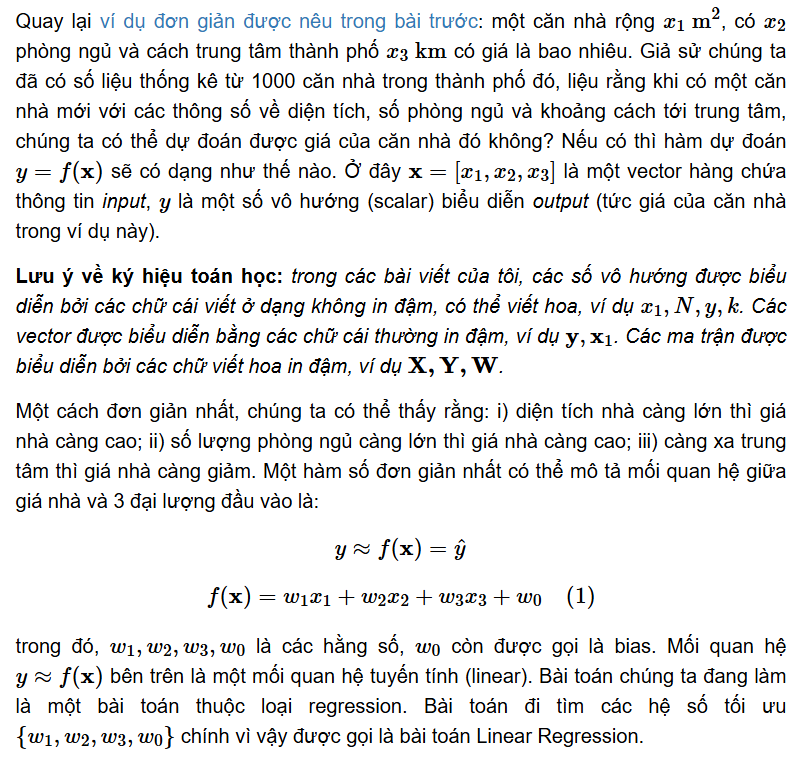
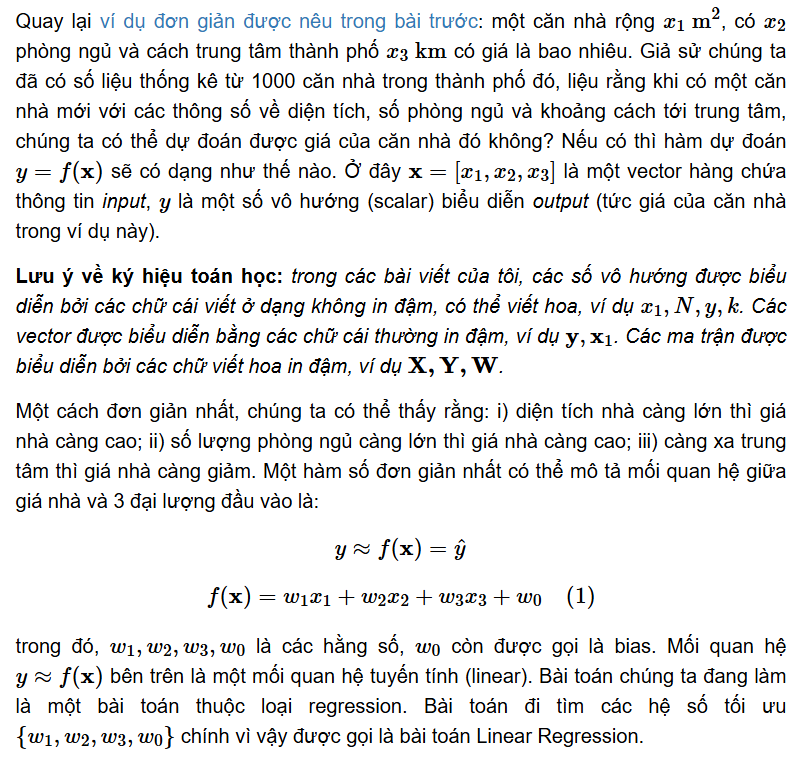

y is the value from the real dataset while y hat is the value that Lr model calculated. y and y hat differ because model error but what we have to do is to minimize this different.

# 2. Theory - Solving mathematics problems

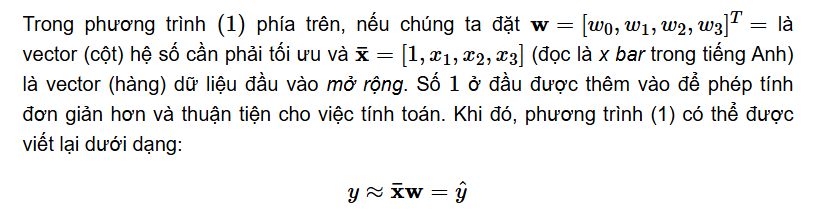

This is the way we turn (1) formula into vector type.

As I mentioned before, our job is to minimize the differtent between y and y hat. So we have the next formula

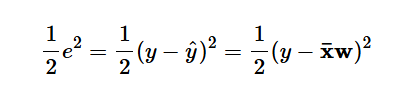

We do the same with every (x,y) and from that, we have the general formula
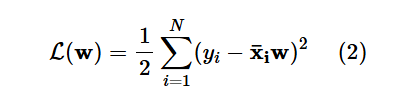

We call this the loss function, and our throughoutly aim is to minimize this function. To do that, we have to calculate the vector w that make this function min. And we call that the optimized point(w*)
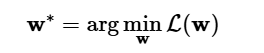

Next, we simplified the loss function by set y=[y1,y2,...,yn] as a column vector including all output of the training data set and x hat =[x1 hat, x2 hat, ...,xn hat] as a input matrix where each row is a data point. The loss function become:

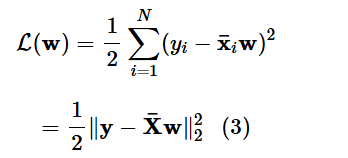

As we know, to find the optimized point, the easiest way is to solve gradient = 0. Luckily, linear make is possible

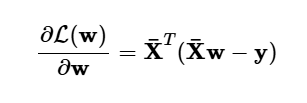
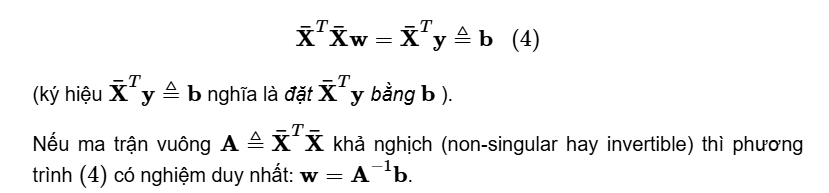

And if the matrix is singular, we use the pseudo-inversers formula
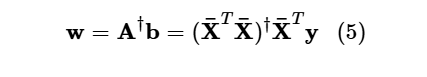

# 2. Apply in Python


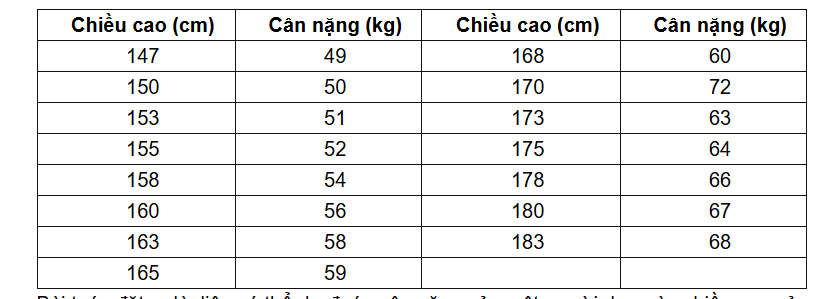

Visibly, height is proportional to weight so we can apply Lr.

1. Input

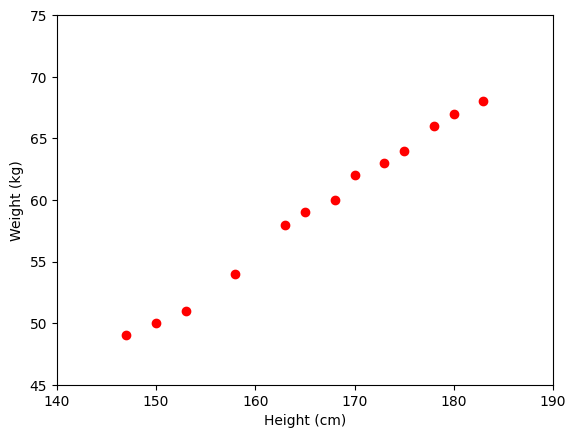

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# height (cm)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
# weight (kg)
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T
# Visualize data 
plt.plot(X, y, 'ro')
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

From this dataset, we can see that all point in the diagram are arranged as a straight line, so Lr would likely give great answer.


weight = *(height) +w_1w_0(5)

* In python, we calculate pseudo inverse by Anumpy.linalg.pinv(A)pinv

w =  [[-33.73541021]
 [  0.55920496]]


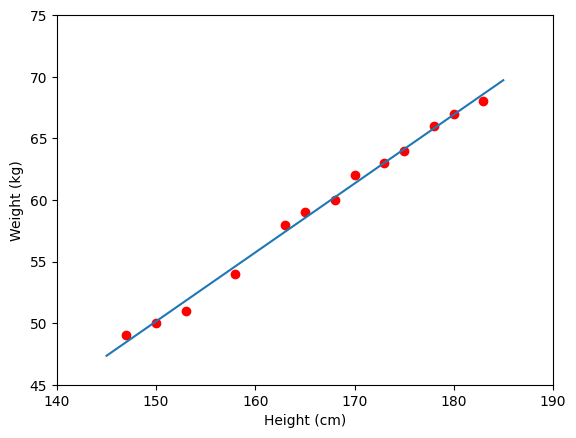

In [2]:
#Building Xbar
one = np.ones((X.shape[0], 1)) #create a column with all 1, has the same line with X
Xbar = np.concatenate((one, X), axis= 1) #concat column with all one in the left

#this is to perform w_0(bias)

# Calculating weights of the fitting line 
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b) #Apply formula (5), always use pinv because its statbility
print('w = ', w)


# Preparing the fitting line 
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

# Drawing the fitting line 
plt.plot(X.T, y.T, 'ro')     # data 
plt.plot(x0, y0)               # the fitting line
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

Lr works well on this dataset, now we will compare output comes from Lr with the real value from the dataset.

In [3]:
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0

print( u'Predict weight of person with height 155 cm: %.2f (kg), real number: 52 (kg)'  %(y1) )
print( u'Predict weight of person with height 160 cm: %.2f (kg), real number: 56 (kg)'  %(y2) )

Predict weight of person with height 155 cm: 52.94 (kg), real number: 52 (kg)
Predict weight of person with height 160 cm: 55.74 (kg), real number: 56 (kg)


The prediction is quite near the real value.

This is how we use Lr. However, Python give us easier way to use Lr, the scikit-learn library. 

In [4]:
from sklearn import datasets, linear_model

# fit the model by Linear Regression
regr = linear_model.LinearRegression(fit_intercept=False) # fit_intercept = False this is to add w0(bias) to X but because we do ot manually before, we set it = false
regr.fit(Xbar, y) #all thing we code is automatically done throught this func

# Compare two results
print( 'Solution found by scikit-learn  : ', regr.coef_ )
print( 'Solution found by (5): ', w.T)

Solution found by scikit-learn  :  [[-33.73541021   0.55920496]]
Solution found by (5):  [[-33.73541021   0.55920496]]


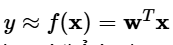

is linear in both w and x. In practice, Lr can also applied for models linear in w. For example:

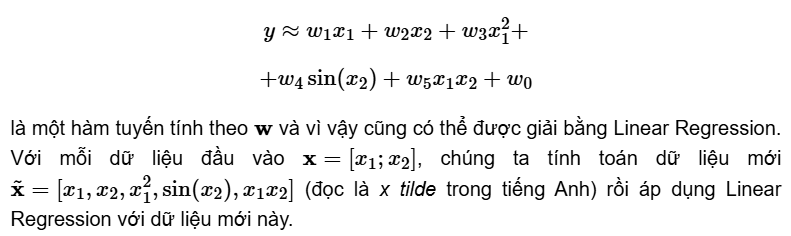

# 3. Restrict
* Lr is sensitive to noise. For example, in the before example, if we add a noise point(150cm, 90kg) will differ answer a lot.
-> To solve this problem, we have to pre-processing, exclude noise before apply Lr.
* Lr cannot perform comlplex model. As mentioned, the equation have not to be linear, but how can we define x1_square, sin(x2), x1x2.

# 4. Conclude
Lr is a simple model, the algorithms is quite simple to. In most case, we cannot solve gradient = 0